In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import jax.numpy as jnp
import numpy as np
import arviz as az
import healpy as hp

sys.path.append("../..")
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band
from utils.utils import find_max_point
from models.scd import dnds
from likelihoods.npll_jax import log_like_np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpyro
import numpyro.distributions as dist

In [23]:
temps

[array([1.36844902, 1.21422632, 0.63442153, 1.21806421, 1.56254457,
        1.03301535, 0.42777859, 1.54977637, 0.41250913, 0.57921492]),
 array([1.58888538, 1.1982108 , 0.21863104, 1.55777891, 1.32958505,
        0.72833684, 1.07452428, 0.78821316, 1.40422551, 0.11160904])]

In [15]:
# multiple templates
n_pix = 10
vd_base = dict(
    S0 = 3,
    S1 = 5,
)
regen_temps = True
if regen_temps:
    for i in range(5):
        z = np.random.uniform(size=n_pix)
        z /= np.mean(z)
        np.save(f'toytemps/toytemp_{i}.npy', z)

In [16]:
include_temps = [0, 1]

save_dir = 'toysim_t' + ''.join([str(i) for i in include_temps])
os.makedirs(save_dir, exist_ok=True)
vd = dict(
    S0 = 3,
    S1 = 5,
)
pickle.dump(vd, open(f"{save_dir}/truth.p", 'wb'))

In [17]:
n_sim = 100

temps = [np.load(f'toytemps/toytemp_{i}.npy') for i in include_temps]

data_s = []
for i_sim in tqdm(range(n_sim)):
    data = np.zeros(n_pix)
    for i in include_temps:
        key = 'S'+str(i)
        S = vd[key]
        data += np.random.poisson(temps[i] * S)
    data_s.append(data)
data_s = np.array(data_s, dtype=np.int64)
np.save(f"{save_dir}/data_s.npy", data_s)

100%|██████████| 100/100 [00:00<00:00, 32298.66it/s]


In [18]:
vd

{'S0': 3, 'S1': 5}

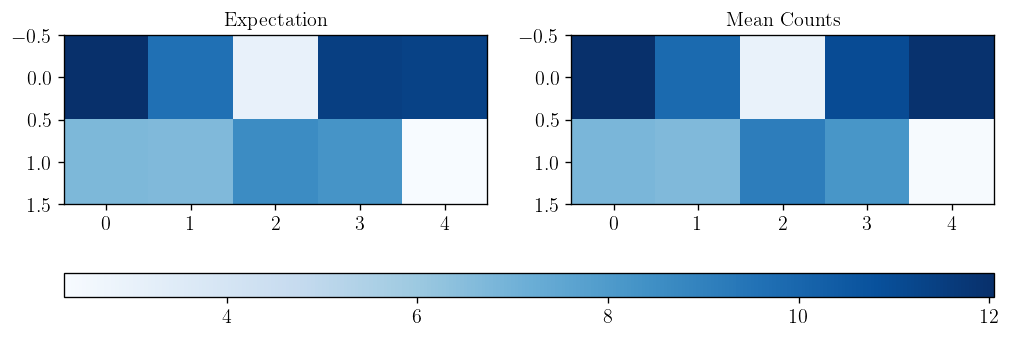

In [19]:
mean_counts = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(n_sim):
    mean_counts += data_s[i]
mean_counts /= float(n_sim)

expectation = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(5):
    if f'S{i}' in vd:
        expectation += temps[i] * vd[f'S{i}']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = np.min(expectation), np.max(expectation)
axs[0].imshow(expectation.reshape(2, 5), vmin=vmin, vmax=vmax, cmap='Blues')
im = axs[1].imshow(mean_counts.reshape(2, 5), vmin=vmin, vmax=vmax, cmap='Blues')
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
axs[0].set_title('Expectation')
axs[1].set_title('Mean Counts');

## analysis

In [24]:
from utils.validation import find_hdi_prob, roc_finite_sample_band

In [25]:
vd

{'S0': 3, 'S1': 5}

In [26]:
truth_dict = vd
samples_dict = {i: pickle.load(open(f"toysim_t01/samples_{i}.p", 'rb')) for i in range(100)}

In [28]:
truth_dict = vd
samples_dict = {i: pickle.load(open(f"toysim_t01/samples_{i}.p", 'rb')) for i in range(100)}

roc_runs = {k : [] for k in truth_dict.keys()}
for ks, samples in tqdm(samples_dict.items()):
    for k in samples.keys():
        v = truth_dict[k]
        # if k in ['zs', 'C', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk']:
        #     continue
        samples_k = np.array(samples[k])
        roc_runs[k].append(find_hdi_prob(samples_k, v, level=15))
for k in roc_runs.keys():
    roc_runs[k] = np.sort(roc_runs[k])

print(list(samples.keys()))

100%|██████████| 100/100 [00:00<00:00, 255.16it/s]

['S0', 'S1']


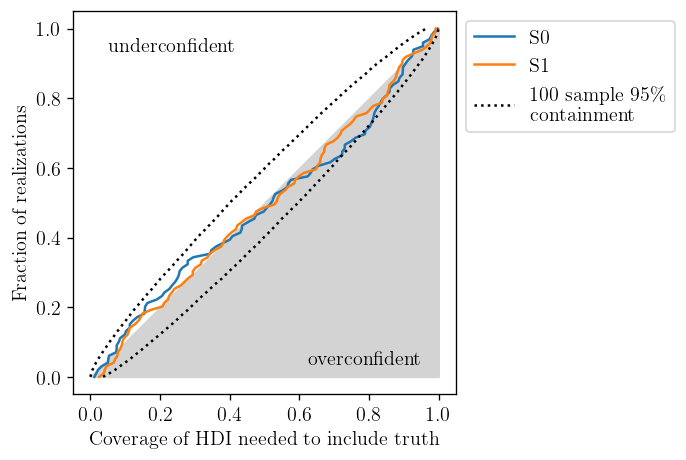

In [29]:
n_run = len(samples_dict)
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

view_keys = list(samples.keys())

linestyles = ['-', '--', ':', '-.']

ax.fill_between([0,1], [0,1], color='lightgray')
for i, (k, roc) in enumerate(roc_runs.items()):
    if k in view_keys:
        ax.plot(roc, np.linspace(0, 1, n_run), label=k, color=f'C{i%10}', linestyle=linestyles[i//10])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout();

In [30]:
import arviz as az

In [40]:
probs = np.linspace(0.001, 1-0.001, 100)

rp_mat0 = np.zeros((100, 100))
rp_mat1 = np.zeros((100, 100))
for ks, samples in tqdm(samples_dict.items()):
    for ip, p in enumerate(probs):
        hdi = az.hdi(np.array(samples['S0']), p)
        rp_mat0[ks, ip] = hdi[0] < truth_dict['S0'] < hdi[1]
        hdi = az.hdi(np.array(samples['S1']), p)
        rp_mat1[ks, ip] = hdi[0] < truth_dict['S1'] < hdi[1]

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:02<00:00, 35.60it/s]


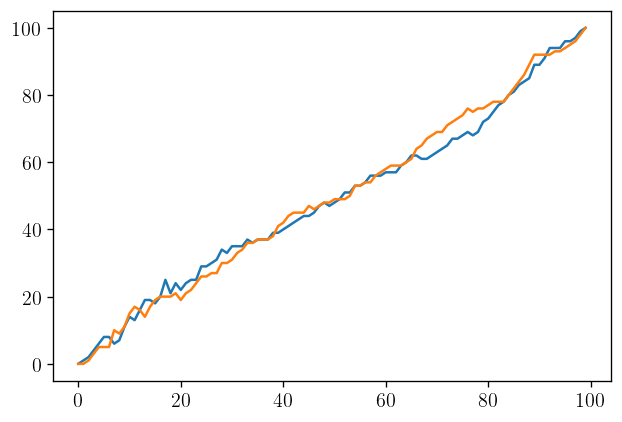

In [43]:
plt.plot(np.sum(rp_mat0, axis=0))
plt.plot(np.sum(rp_mat1, axis=0))

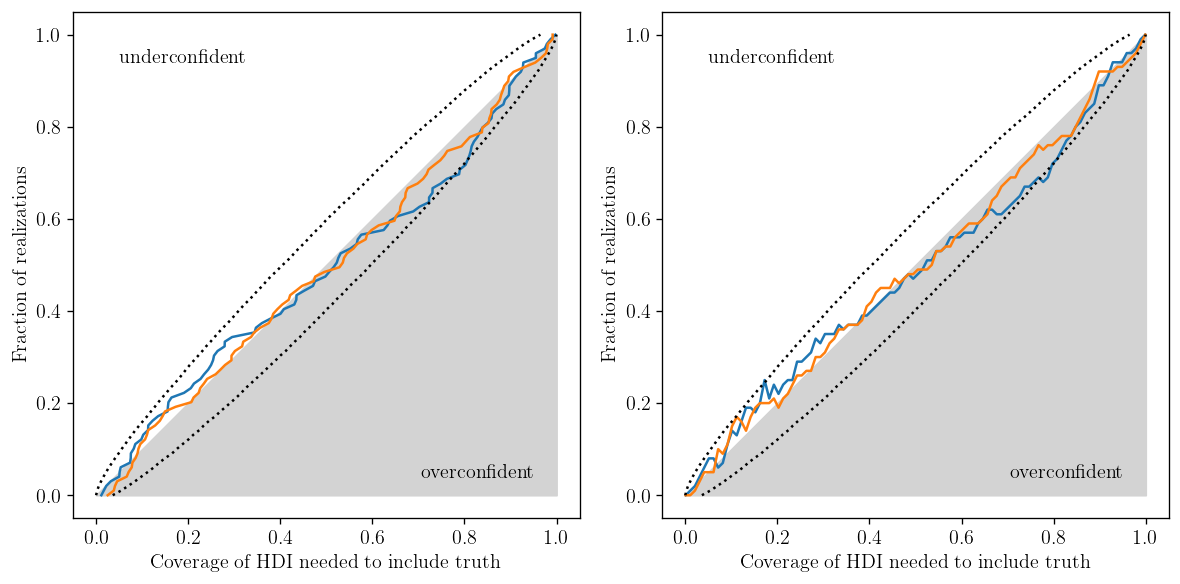

In [45]:
n_run = len(samples_dict)
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

view_keys = list(samples.keys())

linestyles = ['-', '--', ':', '-.']

ax = axs[0]

ax.fill_between([0,1], [0,1], color='lightgray')
for i, (k, roc) in enumerate(roc_runs.items()):
    if k in view_keys:
        ax.plot(roc, np.linspace(0, 1, n_run), label=k, color=f'C{i%10}', linestyle=linestyles[i//10])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

#fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)

ax = axs[1]
ax.plot(probs, np.sum(rp_mat0, axis=0)/100, label='S0')
ax.plot(probs, np.sum(rp_mat1, axis=0)/100, label='S1')
ax.fill_between([0,1], [0,1], color='lightgray')
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')
ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

plt.tight_layout();